# ATLAS Open-Data Statistics Tutorial:  Public models

This is second part of the statistics tutorial using ATLAS open data:
1) Using open-data to run an analysis, run background function fits, then make a likelihood model
2) Re-using public likelihood models

ATLAS makes public the full likelihood model of several published results in the `pyhf` format. You can find them published on the [HEPData](https://www.hepdata.net/) website. This tutorial will walk you through how to download a public likelihood, and re-produce results made in the paper

This tutorial is based on the tutorial from `cabinetry`: https://github.com/cabinetry/cabinetry-tutorials/blob/master/HEPData_workspace.ipynb

## Opening a public likelihood model

We will make use of the `pyhf` package to build these likelihood models right in python. The contents are specified in a `json` format, so they are relatively human readable. We will also make use of `cabinetry` which is built on-top of `pyhf` and has some more options for visualization and such

In [1]:
import json
import pyhf
from pyhf.contrib.utils import download
from pyhf.contrib.viz import brazil
import cabinetry

import logging
logging.getLogger("cabinetry").setLevel(logging.WARNING)
logging.getLogger("pyhf").setLevel(logging.ERROR)

We will first download the `pyhf` file corresponding to search for axion-like particles in ATLAS and load it.
You can find the original open-access publication here: https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/HDBS-2019-19/

Let's pick the file corresponding to an arbitrary signal model investigated

In [2]:
import numpy as np
import matplotlib.pyplot as plt # for plotting

import glob, os #For accessing local files

download("https://www.hepdata.net/record/resource/3587714?view=true","ALP") #download the file from HEPdata
ws = pyhf.Workspace(json.load(open("ALP/fit_jsons/Cyy0p00001_30000_spec.json"))) #load it in python pyhf package

The `pyhf` file (often called a "workspace" in jargon) actually includes 2 pieces of information:
1) The likelihood model: $L(x|{\mathbf\theta})$
2) The data: $x$

A reminder first that ATLAS most usually constructs binned profiled likelihoods in the format:
$$ $L(x|\mathbf{\theta}) = \sum_i Pois(x_i|\mu s_i(\mathbf{\theta})+b_i(\mathbf{\theta})) \sum_j C(\alpha_j|\theta_j)$$
where$\mu$ is the signal strength which is a core piece of the model we are trying to fit (the paramater of interets), the sum $i$ is over all the bins in the fit (often organize this into several regions with several bins, but the likelihood doesnt see this specifically), and $s_i/b_i$ are the signal and background yields in that bin. These are dependent on systematics $\theta_j$, which have constraint terms that provide the effective size of the systematics (usually $C(\alpha_j|\theta_j)=Gauss(0|\theta_j,1)$) 

This seems like alot, but it's just how we convert the hsitograms which correspond to our signal and background (and the correpsonding histograms of their systematcis) into a statistical model.

Note that `pyhf` specifically is only for likelihoods in this format

Let's extract that info!

In [3]:
model =  ws.model()
data   = ws.data(model)

So far it's all super easy!

The `pyhf` workspace is stored in a human-readable `json`. But we can also quickly printout some info to get a better picture of what's in file.

In [4]:
print("\nWorkspace info")
print(f'    channels: {ws.channels}')
print(f'     samples: {ws.samples}')
print(f'   modifiers: {ws.modifiers}')
print(f'       nbins: {ws.channel_nbins}')
#print(f'  parameters: {ws.parameters}')
print(f'observations: {ws.observations}')
print(f' measurement: {ws.measurement_names}')


Workspace info
    channels: ['3Single', '4Single']
     samples: ['Background_3Single', 'Background_4Single', 'Signal_3Single', 'Signal_4Single']
   modifiers: [('PhotonResolution', 'histosys'), ('PhotonScale', 'histosys'), ('Trigger', 'histosys'), ('bkg_est_sys2_3Single', 'histosys'), ('bkg_est_sys2_4Single', 'histosys'), ('lumi', 'lumi'), ('mu', 'normfactor'), ('sig_norm_unc_3Single', 'normsys'), ('sig_norm_unc_4Single', 'normsys'), ('spurious_signal_3Single', 'histosys'), ('spurious_signal_4Single', 'histosys'), ('uncorr_bkguncrt_3Single', 'staterror'), ('uncorr_bkguncrt_4Single', 'staterror'), ('uncorr_siguncrt_3Single', 'staterror'), ('uncorr_siguncrt_4Single', 'staterror')]
       nbins: {'3Single': 14, '4Single': 8}
observations: {'4Single': [10.0, 8.0, 9.0, 13.0, 8.0, 8.0, 10.0, 3.0], '3Single': [765.0, 859.0, 866.0, 780.0, 812.0, 721.0, 664.0, 600.0, 587.0, 491.0, 476.0, 396.0, 293.0, 338.0]}
 measurement: ['meas']


So you can see we have a model with 2 regions (3Single and 4Signal), and 4 histogram templates in total (one signal and one background for each of these regions). There are also several modifiers, which actual just mean different sources of uncertainites.

We can printout even more detailed info from the model configurations, but this is mostly expert level info.

In [5]:
print("\nConfig Info")
print(f'modifiers = {model.config.modifiers}')
print(f' channels = {model.config.channels}')
print(f'  auxdata = {model.config.auxdata}')
print(f' poi_name = {model.config.poi_name}')
print(f'poi_index = {model.config.poi_index}')
print(f'    npars = {model.config.npars}')
print(f'    param = {model.config.par_order}')
print(f'     init = {model.config.suggested_init()}')
print(f'    fixed = {model.config.suggested_fixed()}')
print(f'   bounds = {model.config.suggested_bounds()}')


Config Info
modifiers = [('PhotonResolution', 'histosys'), ('PhotonScale', 'histosys'), ('Trigger', 'histosys'), ('bkg_est_sys2_3Single', 'histosys'), ('bkg_est_sys2_4Single', 'histosys'), ('lumi', 'lumi'), ('mu', 'normfactor'), ('sig_norm_unc_3Single', 'normsys'), ('sig_norm_unc_4Single', 'normsys'), ('spurious_signal_3Single', 'histosys'), ('spurious_signal_4Single', 'histosys'), ('uncorr_bkguncrt_3Single', 'staterror'), ('uncorr_bkguncrt_4Single', 'staterror'), ('uncorr_siguncrt_3Single', 'staterror'), ('uncorr_siguncrt_4Single', 'staterror')]
 channels = ['3Single', '4Single']
  auxdata = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
 poi_name = mu
poi_index = 8
    npars = 55
    param = ['bkg_est_sys2_3Single', 'spurious_signal_3Single', 'PhotonResolution', 

In [6]:
print("\n Param info")
for k in model.config.par_order:
  print(f'  {k}')
  print(f'\tparam_set={model.config.param_set(k)}')
  print(f'\tn_parameters={model.config.param_set(k).n_parameters}')
  print(f'\tconstrained={model.config.param_set(k).constrained}')
  if model.config.param_set(k).constrained:
    print(f'\tpdf={model.config.param_set(k).pdf_type}')
    print(f'\tauxdata={model.config.param_set(k).auxdata}')
    #print(f'\tfactors={model.config.param_set(k).factors}')
    print(f'\twidth={model.config.param_set(k).width()}')
  print(f'\tinit={model.config.param_set(k).suggested_init}')
  print(f'\tbounds={model.config.param_set(k).suggested_bounds}')
  print(f'\tfixed={model.config.param_set(k).suggested_fixed}')
  print(f'\tslice={model.config.par_slice(k)}')


 Param info
  bkg_est_sys2_3Single
	param_set=<pyhf.parameters.paramsets.constrained_by_normal object at 0x7fc8d896c390>
	n_parameters=1
	constrained=True
	pdf=normal
	auxdata=[0.0]
	width=[1.0]
	init=[0.0]
	bounds=[(-5.0, 5.0)]
	fixed=[False]
	slice=slice(0, 1, None)
  spurious_signal_3Single
	param_set=<pyhf.parameters.paramsets.constrained_by_normal object at 0x7fc8d896c490>
	n_parameters=1
	constrained=True
	pdf=normal
	auxdata=[0.0]
	width=[1.0]
	init=[0.0]
	bounds=[(-5.0, 5.0)]
	fixed=[False]
	slice=slice(1, 2, None)
  PhotonResolution
	param_set=<pyhf.parameters.paramsets.constrained_by_normal object at 0x7fc8d896f7d0>
	n_parameters=1
	constrained=True
	pdf=normal
	auxdata=[0.0]
	width=[1.0]
	init=[0.0]
	bounds=[(-5.0, 5.0)]
	fixed=[False]
	slice=slice(2, 3, None)
  PhotonScale
	param_set=<pyhf.parameters.paramsets.constrained_by_normal object at 0x7fc8d896f690>
	n_parameters=1
	constrained=True
	pdf=normal
	auxdata=[0.0]
	width=[1.0]
	init=[0.0]
	bounds=[(-5.0, 5.0)]
	fixed=[F

So let's get to the fun part! Let's use cabinetry to dump a table of all the sample yield in each region. You can often find a table like this in public results.

In [7]:
prediction_prefit = cabinetry.model_utils.prediction(model)
table = cabinetry.tabulate.yields(prediction_prefit, data, per_channel=True, per_bin=False)

#Open the file cabinetry makes here
with open("tables/yields_per_channel_pre-fit.txt") as f: 
    print(f.read())

sample              3Single            4Single
------------------  -----------------  ------------
Background_3Single  8694.84 ± 1951.12  0.00 ± 0.00
Background_4Single  0.00 ± 0.00        65.00 ± 5.73
Signal_3Single      2.99 ± 0.19        0.00 ± 0.00
Signal_4Single      0.00 ± 0.00        1.53 ± 0.14
total               8697.83 ± 1951.12  66.53 ± 5.73
data                8648.00            69.00



And maybe even more interestingly we can make a plot of the distributions!

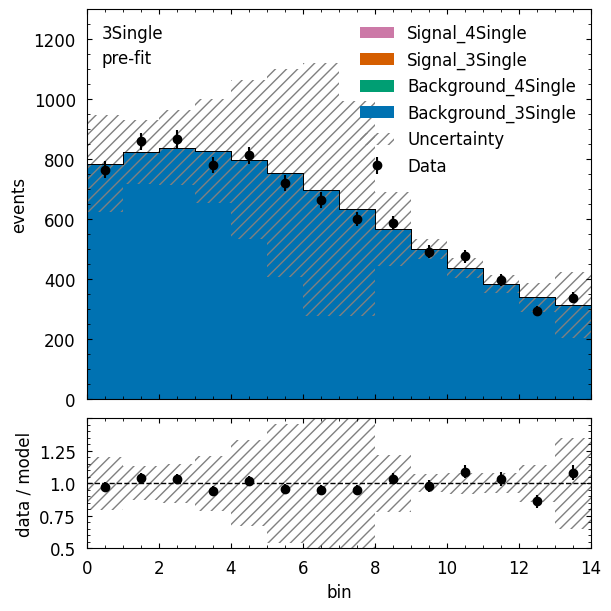

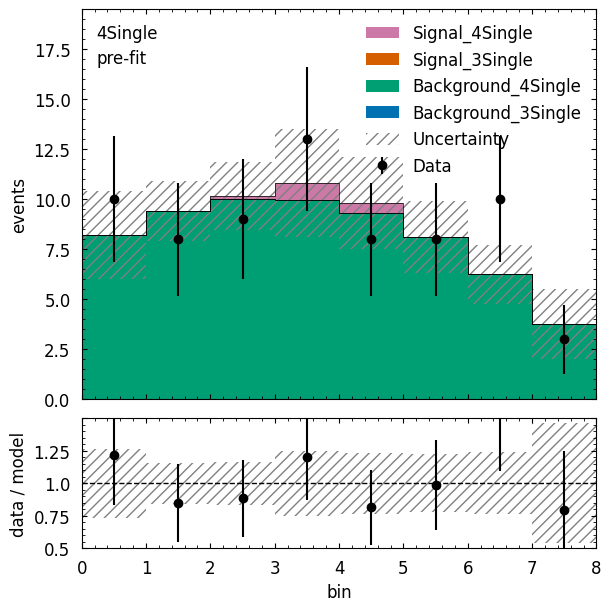

In [8]:
_ = cabinetry.visualize.data_mc(prediction_prefit, data)

Now let's run a fit! We will run a "conditional" fit where we fix the poi to zero in the fit.

We can see some big uncertainty bands here, probably due to some conservative choices of uncertainities

In [9]:
#Set the intial paramaters to default, and the poi=0
init_pars = model.config.suggested_init()
init_pars[model.config.poi_index] = 0

#Set the poi to a fixed parameter
fix_pars = model.config.suggested_fixed()
fix_pars[model.config.poi_index] = True

#run a fit with poi fixed to 0
fit_results = cabinetry.fit.fit(model, data, init_pars=init_pars, fix_pars=fix_pars)

Now let's run the display of model after the fit

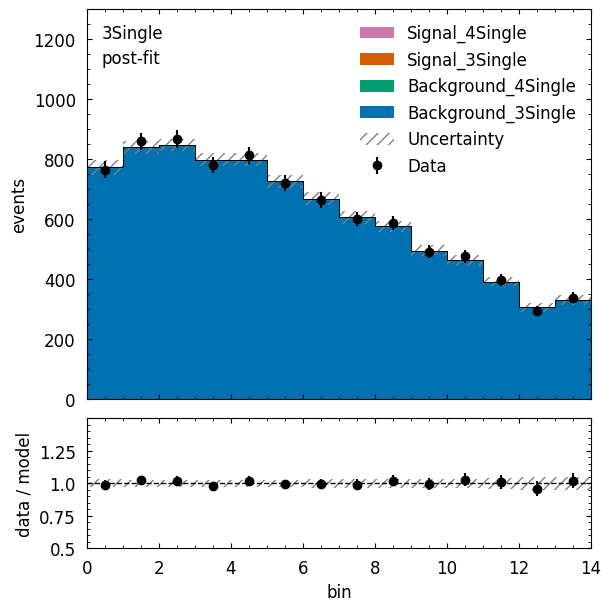

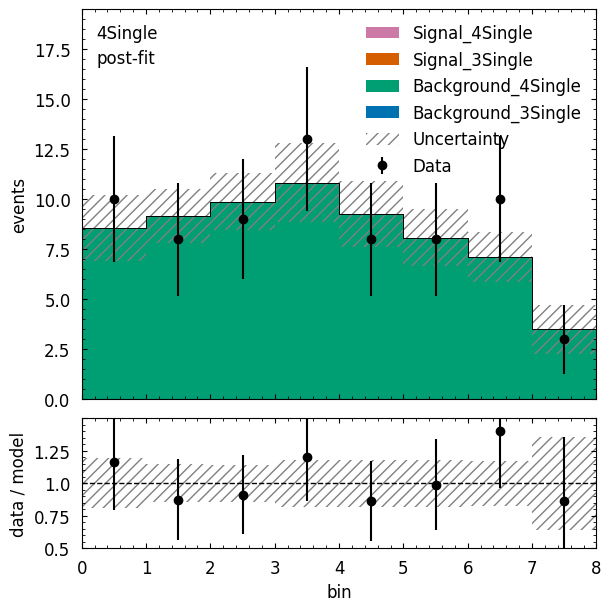

In [10]:
prediction_postfit = cabinetry.model_utils.prediction(model, fit_results=fit_results)
_ = cabinetry.visualize.data_mc(prediction_postfit, data)

We see that the uncertainties are smaller then before! Since we give each systematic a parameter $\theta$ in the model, the data itself allows us to constrain the size of the systematics if they were originall conservative. This is one of the powers of the profiled likelihood fit approach we use!

To help visualize this effect, we can make a "pull plot". Where what is shown is the different in postfit vs prefit values of each of the systematic $\theta$, divided by the size of the uncertainity. 

A pull value of:
- $0\pm1$ means the fit doesn't really alter the systematic. 
- A center away from 0 means that the fit prefers a value different then the originall provided values
- A uncertainity < 1 means the data in the fit can actually constrain the impact of this systematics better then the original value in the model
So we can see some things like the bakcground estimate snd spurious signal uncertainities (what those physically mean you should try to decipher from paper text) have been constrained in the fit and provide a more accurate prediction!

(We can ignore the `uncorr_*` systematics in this discussion which are treated differently with a Poisson constraint term as opposed to a conventional Gaussian. What is actually displayed in these pull plots is instead just the raw fitted value and uncertainty (no centering and scaling as I mentioned before))

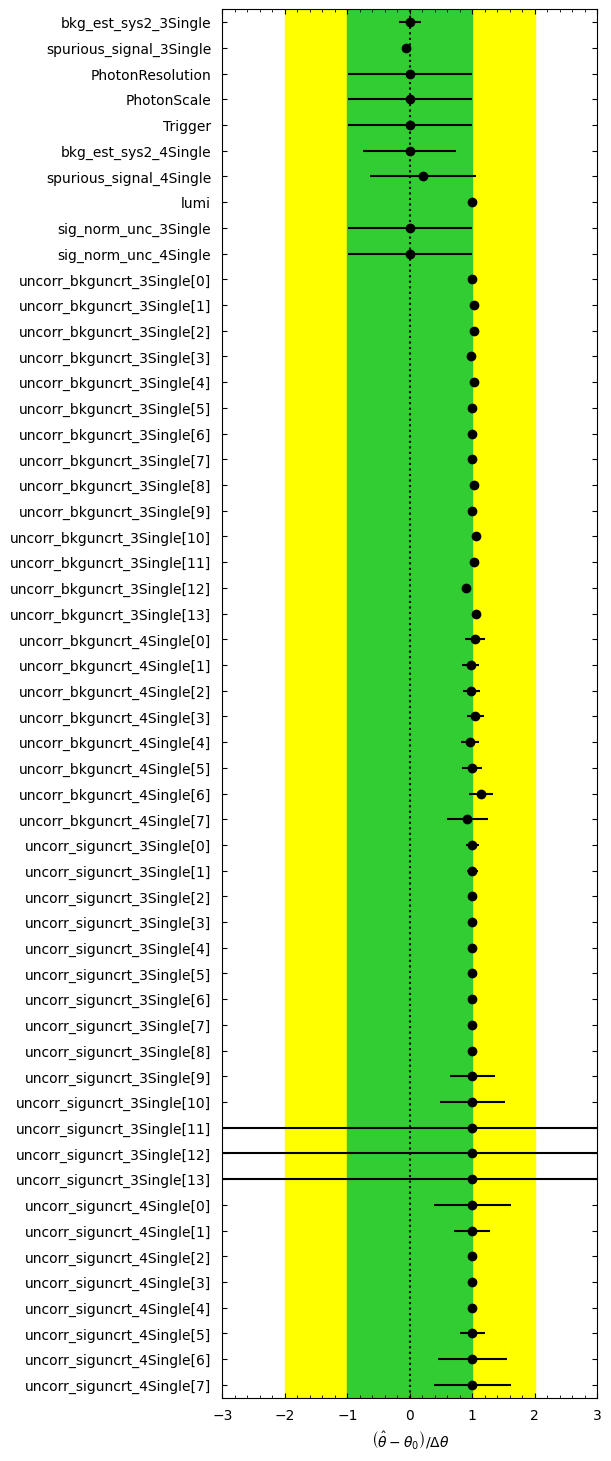

In [11]:
cabinetry.visualize.pulls(fit_results)

We can also plot the correlations of the parmaters of the fit, which can have some illumnating results sometimes.

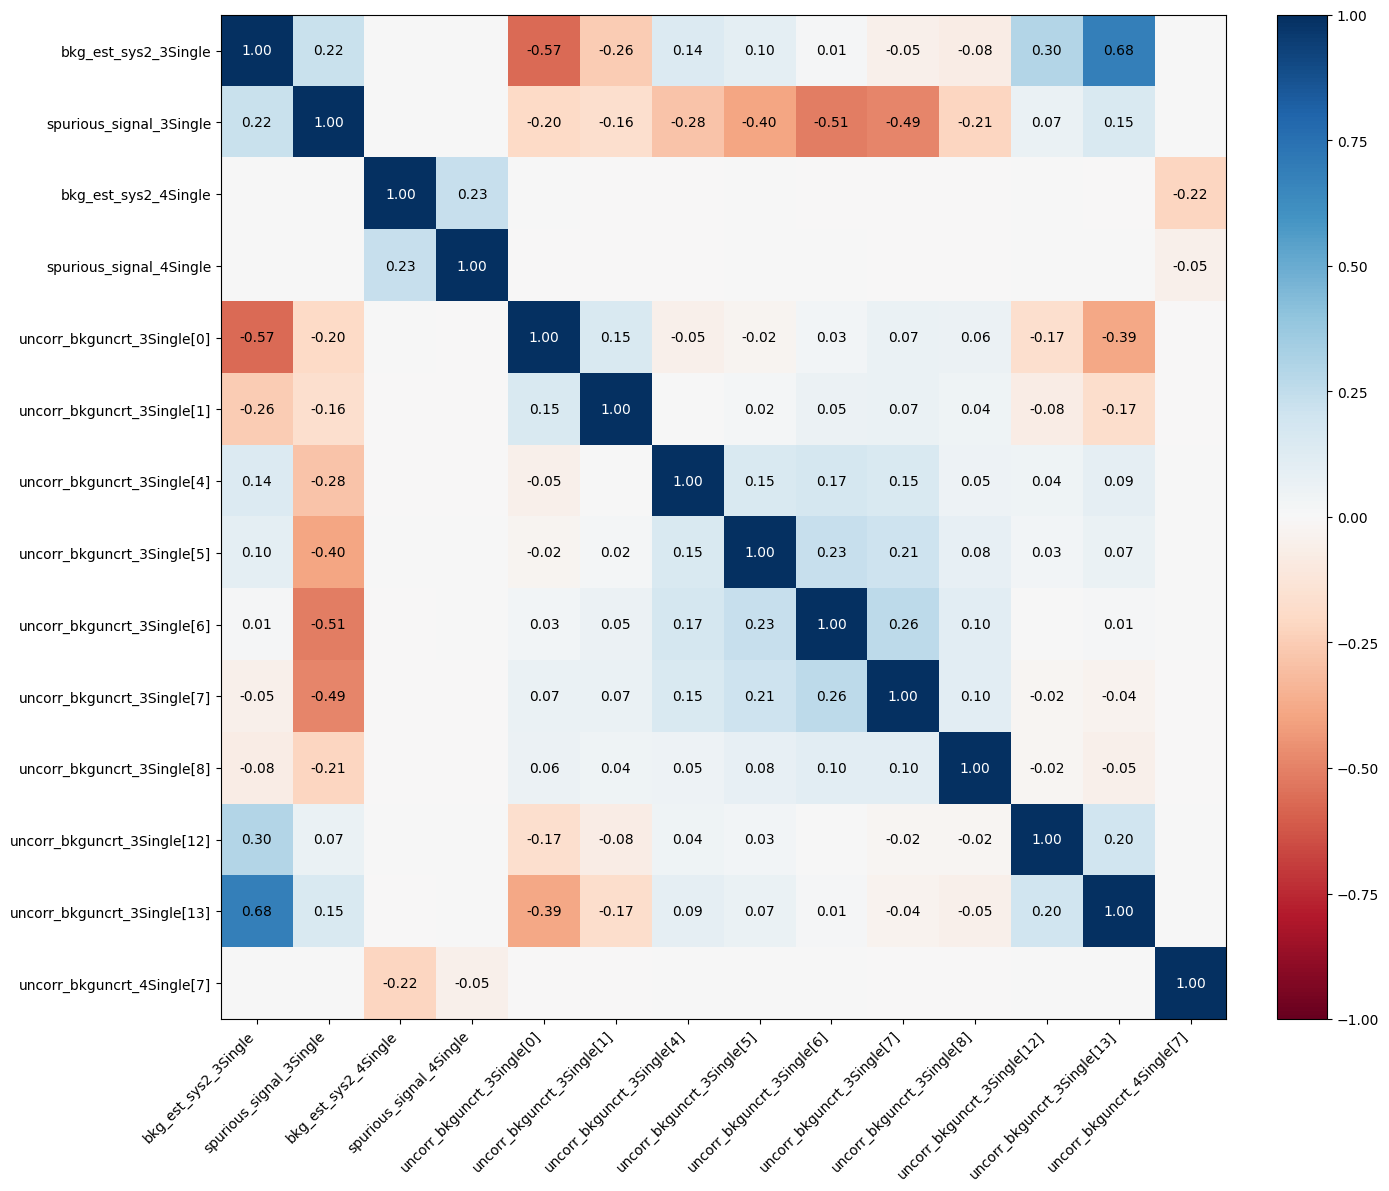

In [12]:
cabinetry.visualize.correlation_matrix(fit_results, pruning_threshold=0.2)

## Running limits

Okay now let's run limits, the first thing to remember is that a statistical hypothesis test is always with respect to a definitive signal model, this means a specific mass and also signal strength for this analysis. To get the upper limit at a mass point, we scan through the signal strengths until we find the p-value=0.05 crossing, which corresponds to a 95% confidence interval

This is pretty easy with phyf, and let's visualize the scan. This may take awhile, so we'll set the run the limits with all the systematics turned off for now

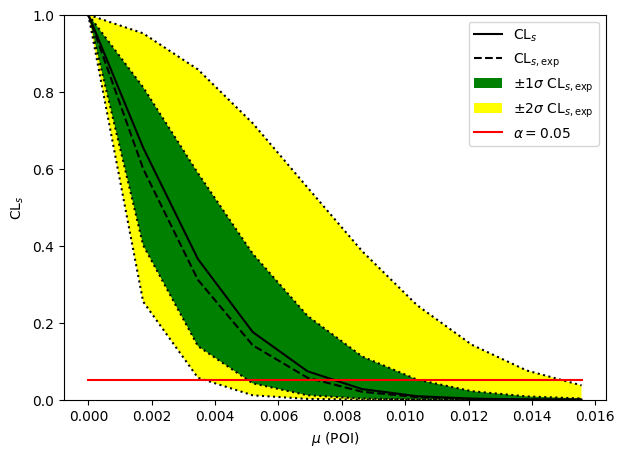

In [13]:
#Run stat-only. Replace this with model.config.suggested_fixed() otherwise or remove the argument to below functions
fixed_params = [p!= model.config.poi_name for p in model.config.par_names]

fit_results = cabinetry.fit.fit(model, data,fix_pars=fixed_params)

mu_values=np.linspace(0,5*fit_results.uncertainty[model.config.poi_index],10) # the mu values to run over, we'll be smart
results = [
    pyhf.infer.hypotest(mu, data, model, test_stat="qtilde", return_expected_set=True,fixed_params=fixed_params)
    for mu in mu_values
] # get the p-value for each of these scanned mu values

#make plot of the limit scan for this mass point
fig, ax = plt.subplots()
fig.set_size_inches(7, 5)
brazil.plot_results(mu_values, results, ax=ax)
fig.show()

So the intersection of the observed, and expected curves with the red line are our limits at that mass point

Now let's run it over all the masses.

In [14]:
stat_only=True

#Dictionary to store all the results
results = { 
        "obs": [],
        "median": [], 
        "minus1": [], "minus2": [], 
        "plus1": [], "plus2": [] 
}

#Let's find all the mass points
patchsets=sorted(glob.glob("ALP/fit_jsons/Cyy0p00001_*.json"))
for patch in patchsets:
    # Load the workspace for this point
    patched_ws = pyhf.Workspace(json.load(open(patch)))
    patched_model =  patched_ws.model()
    patched_data = patched_ws.data(patched_model)
    
    #Fix systematics if we want
    if stat_only:
        fixed_params = [p!= patched_model.config.poi_name for p in patched_model.config.par_names] # use par_names not parameters for uncert with multiple components
    else:
        fixed_params= model.config.suggested_fixed()
    
    #Similar dictionary to hold the scan results for each patchset
    CLs = { 
        "obs": [],
        "median": [], 
        "minus1": [], "minus2": [], 
        "plus1": [], "plus2": [] 
    }
    
    #Be a bit smart and get a scan range based on the poi uncertainity for this point
    fit_results = cabinetry.fit.fit(patched_model, patched_data,fix_pars=fixed_params)
    mu_values=np.linspace(0,5*fit_results.uncertainty[patched_model.config.poi_index],10)
    
    par_bounds=model.config.suggested_bounds() 
    if par_bounds[model.config.poi_index][0]<0: par_bounds[model.config.poi_index][0]=0
    
    #Scan over poi values
    for mu in mu_values:
        # Calculate CLs
        obs,bands = pyhf.infer.hypotest(mu, patched_data, patched_model, test_stat="qtilde", return_expected_set=True, fixed_params=fixed_params)
        CLs["obs"].append(obs)
        CLs["median"].append(bands[2])
        CLs["plus2"].append(bands[0])
        CLs["plus1"].append(bands[1])
        CLs["minus1"].append(bands[3])
        CLs["minus2"].append(bands[4])
        
    # Interpolate where CLs = 0.05 and save it
    results["obs"].append(np.interp(0.05, CLs["obs"][::-1], mu_values[::-1]).item()) #[::-1] just to reverse the list for np.interp
    results["median"].append(np.interp(0.05, CLs["median"][::-1], mu_values[::-1]).item())
    results["minus1"].append(np.interp(0.05, CLs["minus1"][::-1], mu_values[::-1]).item())
    results["minus2"].append(np.interp(0.05, CLs["minus2"][::-1], mu_values[::-1]).item())
    results["plus1"].append(np.interp(0.05, CLs["plus1"][::-1], mu_values[::-1]).item())
    results["plus2"].append(np.interp(0.05, CLs["plus2"][::-1], mu_values[::-1]).item())
    
    mass=float(patch.split("/")[-1].split("_")[1])/1000 #get mass point for a nicer printout
    print("For mass=%3f limits: obs=%.4f, exp={%.4f, bands=(%.4f,%.4f,%.4f,%.4f)"%(mass,results["obs"][-1],results["median"][-1],results["minus2"][-1],results["minus1"][-1],results["plus1"][-1],results["plus2"][-1]))

For mass=10.000000 limits: obs=1.0854, exp={0.6749, bands=(1.5631,1.0377,0.4620,0.3303)
For mass=11.000000 limits: obs=0.9831, exp={0.5839, bands=(1.3639,0.9011,0.3972,0.2864)
For mass=12.000000 limits: obs=0.5492, exp={0.3232, bands=(0.7261,0.4899,0.2244,0.1603)
For mass=13.000000 limits: obs=0.2307, exp={0.1225, bands=(0.2752,0.1851,0.0836,0.0624)
For mass=14.000000 limits: obs=0.1360, exp={0.0746, bands=(0.1667,0.1128,0.0513,0.0376)
For mass=15.000000 limits: obs=0.0664, exp={0.0341, bands=(0.0773,0.0514,0.0232,0.0176)
For mass=16.000000 limits: obs=0.0423, exp={0.0213, bands=(0.0484,0.0320,0.0145,0.0111)
For mass=17.000000 limits: obs=0.0292, exp={0.0144, bands=(0.0329,0.0217,0.0097,0.0075)
For mass=18.000000 limits: obs=0.0214, exp={0.0103, bands=(0.0237,0.0157,0.0069,0.0055)
For mass=19.000000 limits: obs=0.0170, exp={0.0083, bands=(0.0190,0.0126,0.0056,0.0044)
For mass=20.000000 limits: obs=0.0134, exp={0.0064, bands=(0.0148,0.0098,0.0043,0.0034)
For mass=21.000000 limits: obs=0

/srv/conda/envs/notebook/lib/python3.11/site-packages/pyhf/infer/calculators.py:418: RuntimeWarning: divide by zero encountered in scalar divide
  teststat = (qmu - qmu_A) / (2 * self.sqrtqmuA_v)
/srv/conda/envs/notebook/lib/python3.11/site-packages/pyhf/infer/calculators.py:467: RuntimeWarning: invalid value encountered in divide
  CLs = tensorlib.astensor(CLsb / CLb)


For mass=40.000000 limits: obs=0.0086, exp={0.0091, bands=(0.0181,0.0131,0.0065,0.0046)
For mass=41.000000 limits: obs=0.0076, exp={0.0077, bands=(0.0155,0.0112,0.0056,0.0040)
For mass=42.000000 limits: obs=0.0071, exp={0.0074, bands=(0.0148,0.0107,0.0054,0.0038)
For mass=43.000000 limits: obs=0.0067, exp={0.0069, bands=(0.0138,0.0100,0.0050,0.0035)
For mass=44.000000 limits: obs=0.0065, exp={0.0067, bands=(0.0134,0.0097,0.0049,0.0034)
For mass=45.000000 limits: obs=0.0060, exp={0.0062, bands=(0.0124,0.0090,0.0045,0.0032)
For mass=46.000000 limits: obs=0.0058, exp={0.0059, bands=(0.0118,0.0086,0.0043,0.0030)
For mass=47.000000 limits: obs=0.0056, exp={0.0057, bands=(0.0113,0.0082,0.0041,0.0029)
For mass=48.000000 limits: obs=0.0053, exp={0.0054, bands=(0.0108,0.0078,0.0039,0.0028)
For mass=49.000000 limits: obs=0.0052, exp={0.0052, bands=(0.0105,0.0076,0.0038,0.0027)
For mass=50.000000 limits: obs=0.0048, exp={0.0049, bands=(0.0098,0.0071,0.0035,0.0025)
For mass=51.000000 limits: obs=0

Now let's make the famous limit plots!

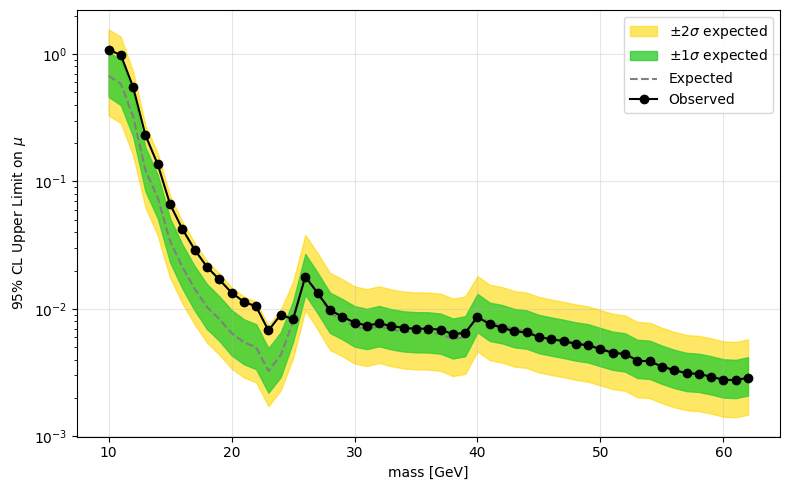

In [15]:
plt.figure(figsize=(8,5))
x = [ float(patch.split("/")[-1].split("_")[1])/1000 for patch in patchsets] #finding the mass point from the file name, would be different for other publications

# +/-  1/2sigma band (green,yellow)
plt.fill_between(x, results["minus2"], results["plus2"], color="gold", label=r"$\pm 2\sigma$ expected", alpha=0.6)
plt.fill_between(x, results["minus1"], results["plus1"], color="limegreen", label=r"$\pm 1\sigma$ expected", alpha=0.8)

# Median expected
plt.plot(x, results["median"], linestyle="--", color="gray", label="Expected")

# Observed
plt.plot(x, results["obs"], linestyle="-", color="black", marker="o", label="Observed")

#Some nice labels
plt.xlabel("mass [GeV]")
plt.ylabel(r"95% CL Upper Limit on $\mu$")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


We can compare this to the result from the publication below. If we re-run with the systemtatics enabled you should compeletly reproduce the plot

![](https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/HDBS-2019-19/fig_06d.png)

## Measurements

We can also run similar studies for likelihood models corresponding to precision measurments.

Let's use the public model corresponding to a measurement of top-quark pair production
https://atlas.web.cern.ch/Atlas/GROUPS/PHYSICS/PAPERS/TOPQ-2020-02/

Let's download it and make some plots like before

In [16]:
if not os.path.exists("likelihood_ttbar_ljets_13TeV_fiducial.json"): # These files stored in a zipped directory on hepdata\n",
    import requests, zipfile, io
    response = requests.get("https://www.hepdata.net/record/resource/3112455?view=true")
    z = zipfile.ZipFile(io.BytesIO(response.content))
    for fname in z.namelist():
        if not "README" in fname:
            z.extract(fname)
            outname=fname.replace(".json","_pruned.json")
            !pyhf prune -t staterror $fname > $outname #README of the hepdata says to do this\n",
ws = pyhf.Workspace(json.load(open("likelihood_ttbar_ljets_13TeV_fiducial_pruned.json")))
model =  ws.model()
data   = ws.data(model)

First let's run the fit, and make plots of the distributions as before. We'll update the color-scheme to look more similar to the plots you can find in the paper

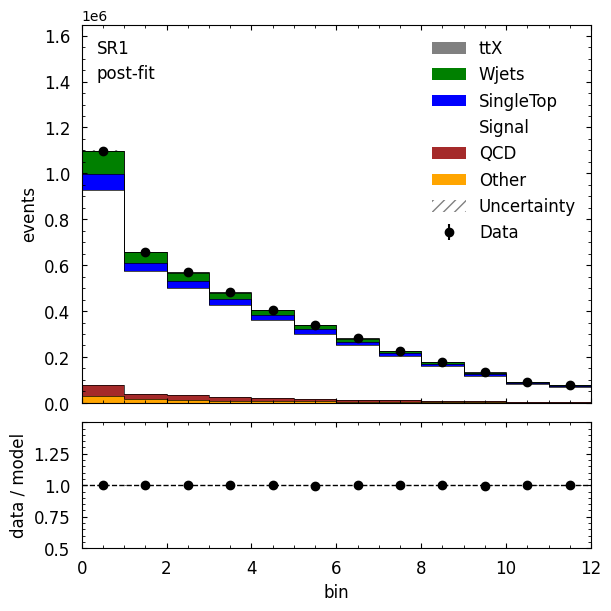

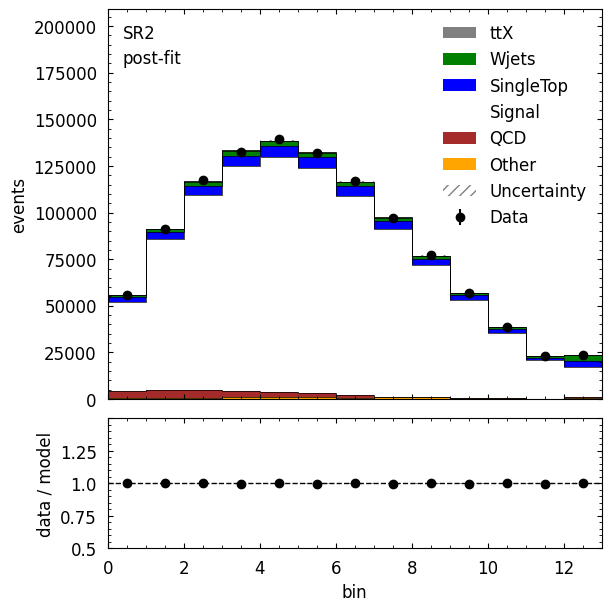

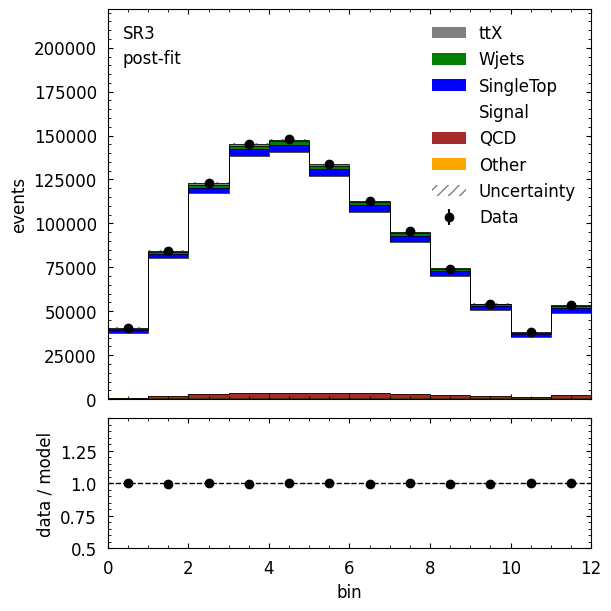

In [17]:
fit_results = cabinetry.fit.fit(model, data)
prediction_postfit = cabinetry.model_utils.prediction(model, fit_results=fit_results)
colorDict={"Signal":"white", "ttX":"gray", "Wjets":"green", "SingleTop":"blue", "QCD":"brown", "Other":"orange"}
_ = cabinetry.visualize.data_mc(prediction_postfit, data,colors=colorDict)

And as before let's run the pulls and correlation plots

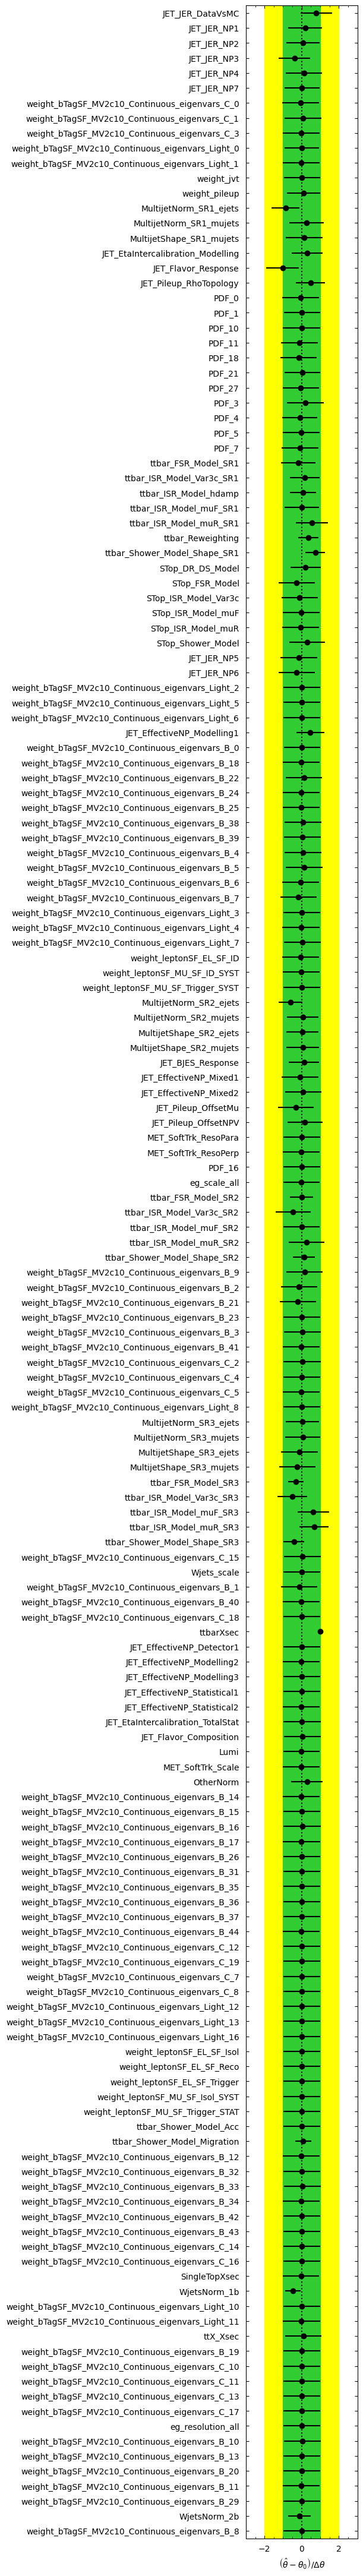

In [18]:
cabinetry.visualize.pulls(fit_results)

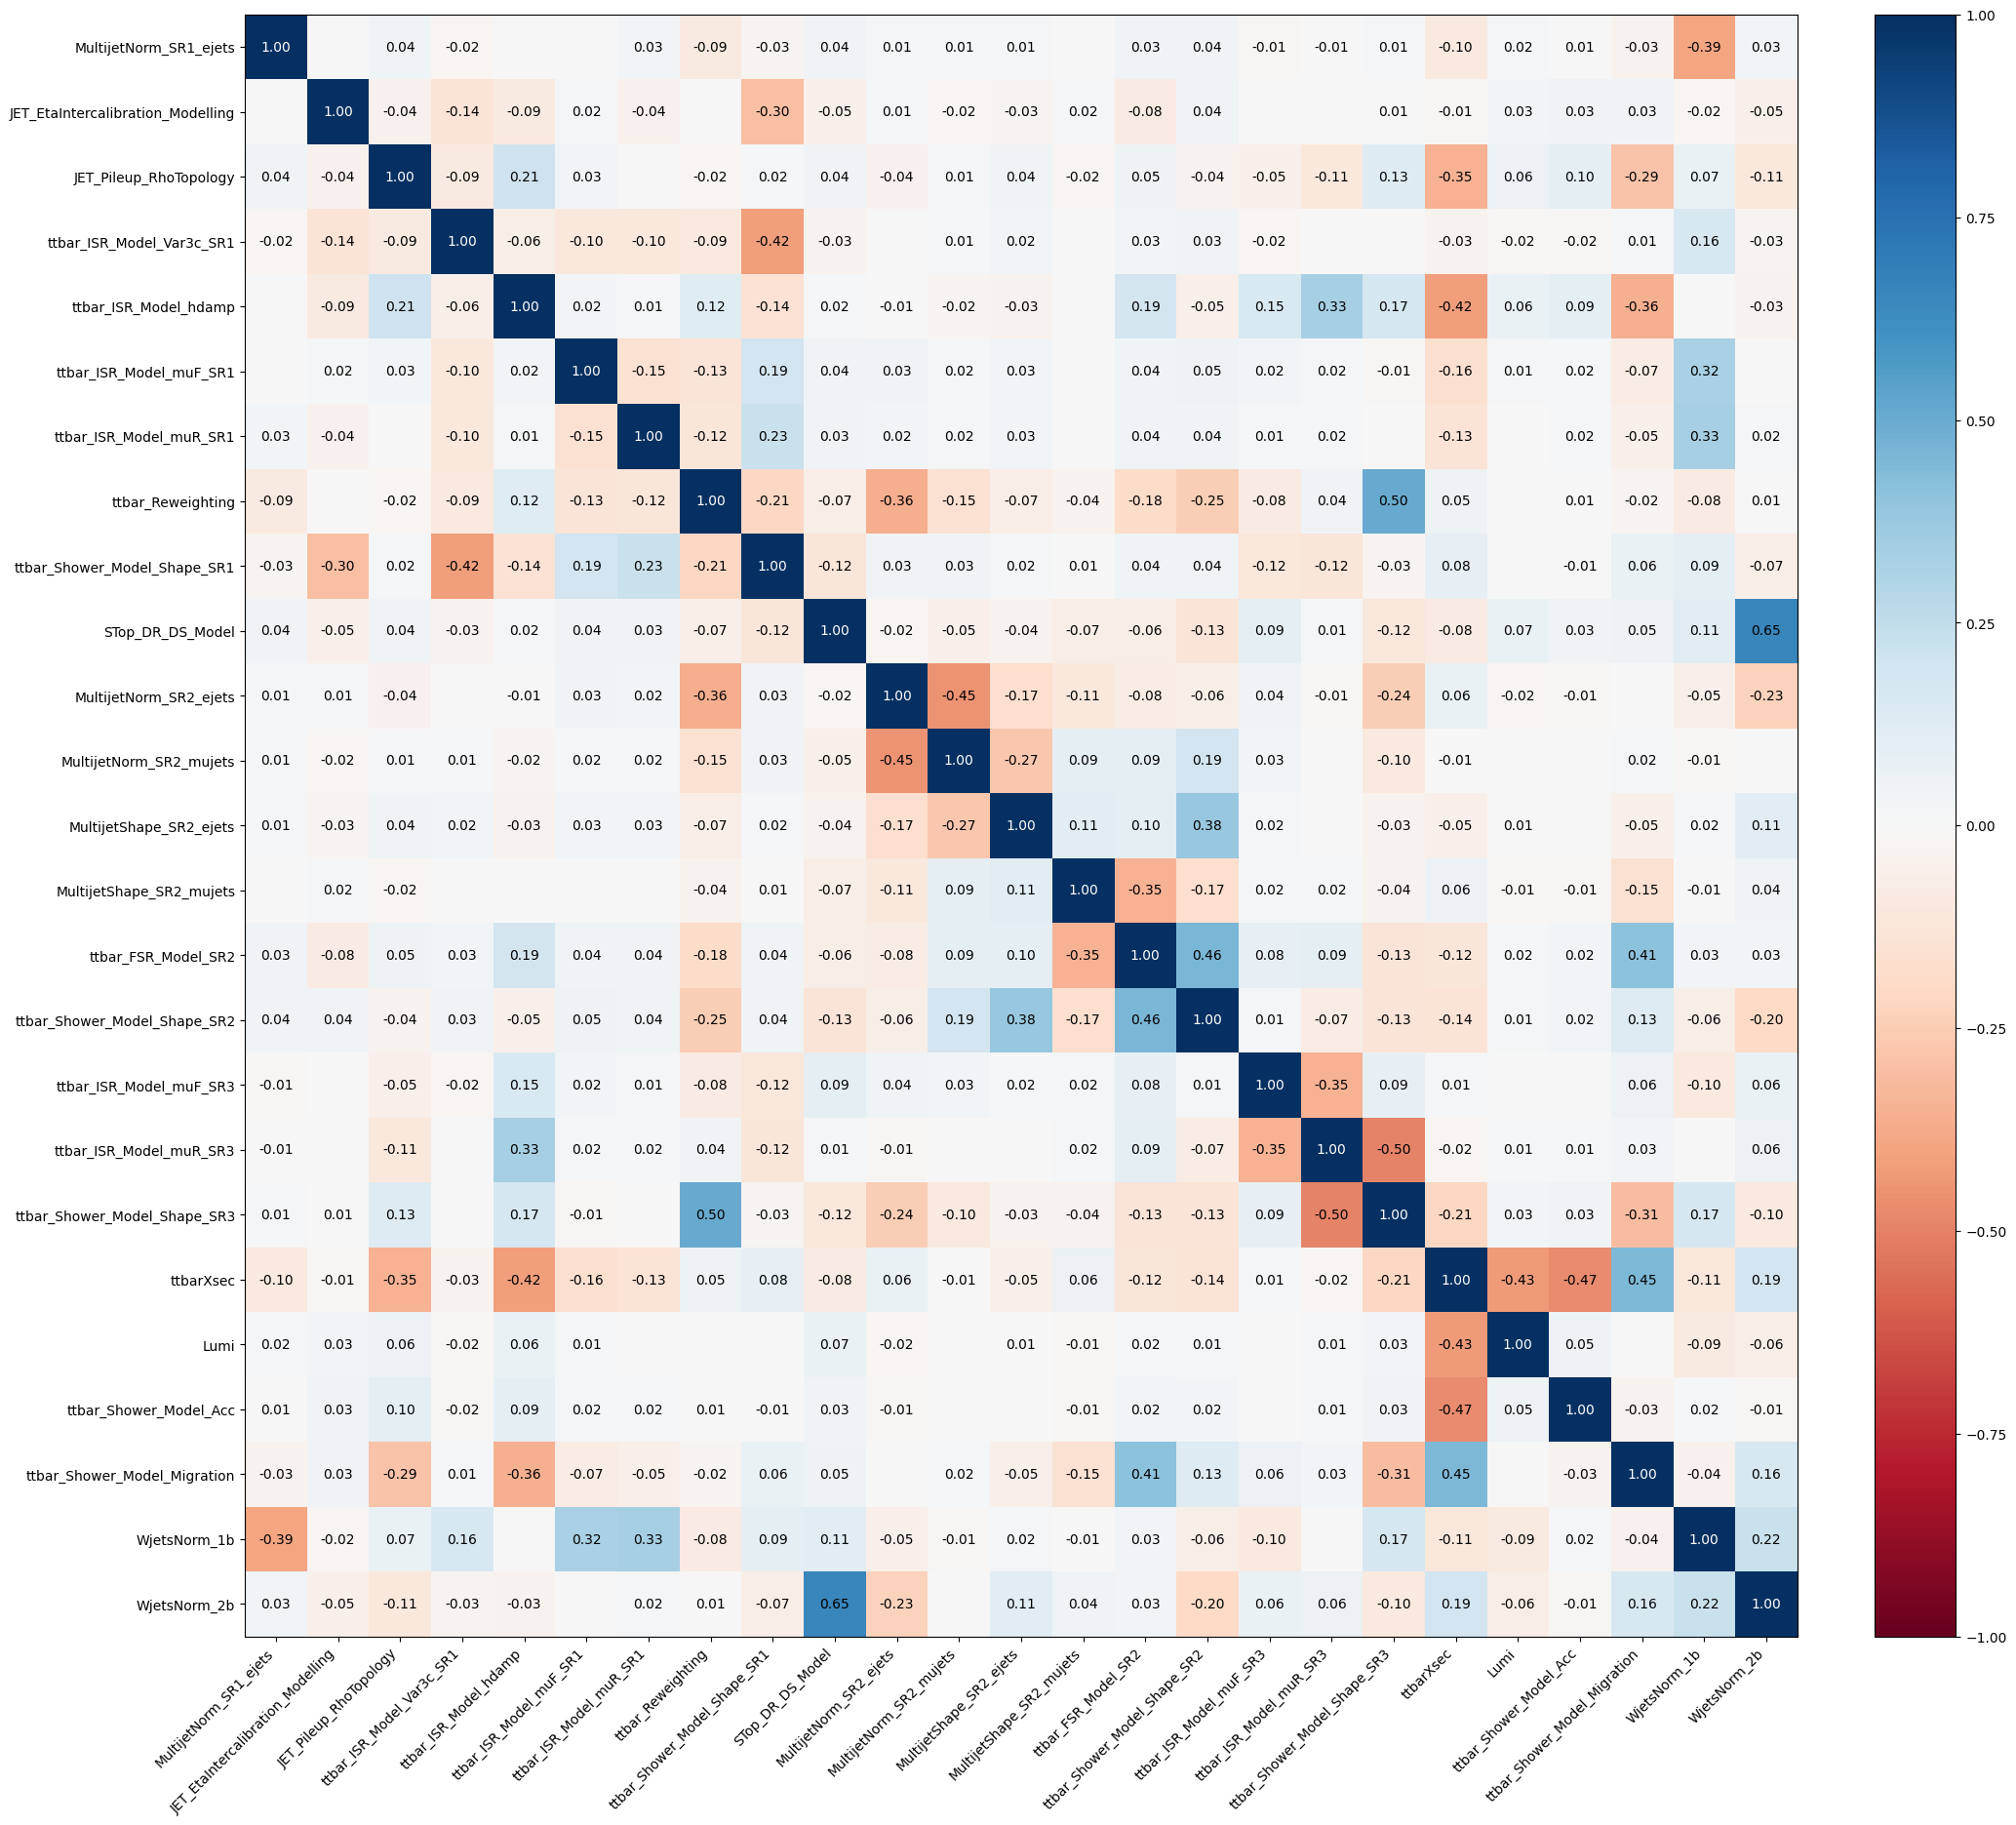

In [19]:
cabinetry.visualize.correlation_matrix(fit_results, pruning_threshold=0.3)

You can see they are much more intricate in this case, which is also why the fits take much longer

For fun let's run the signal significance calculation. To make things faster we'll just run on a subset of the systematics

In [20]:
#Remove some of the minor systematics to make the rest of the fits faster
fixed_params = ["Norm" not in p and not "JET" in p and not "ttbar" in p and not "PDF" in p and not "Lumi" in p
                for p in model.config.par_names] 

#Run the significance test
significance_results = cabinetry.fit.significance(model, data,fix_pars=fixed_params)
print(f"Observed p-value={significance_results.observed_p_value}, Expected p-value={significance_results.expected_p_value}")

Observed p-value=0.0, Expected p-value=0.0


You can see it outputs a p-value=0, which is just due to numerical limitation. In reality it's an absolutely tiny p-value, which makes sense if you look at the distributions. It's clear you would need the signal process (white) for the data to make any remote sense (the background-only hypothesis is very incompatible with the data = tiny p-value)

We'll do one more thing you may often see in measurement papers, which is a scan of the negative log-likelihood. This is a handy visualization of the likelihood itself, where the minimum corresponds to the best fit value, and certain horizontal slices correspond to 68/95% confidence intervals on the parameters being scanned over.

This may take some time on this model with lots of parameters

In [21]:
#Let's use a smart scan range based on our previous fit
mu=fit_results.bestfit[model.config.poi_index]
uncert=fit_results.uncertainty[model.config.poi_index]

#Run the scan via cabinetry
scan_results = cabinetry.fit.scan(model, data, model.config.poi_name, par_range=[mu-3*uncert,mu+3*uncert], fix_pars=fixed_params)

Text(1.0900948428906077, 2.2, '95% CL')

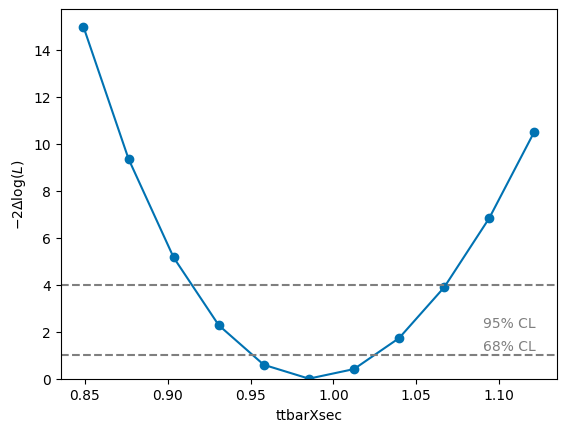

In [22]:
#Make the figure
fig=plt.figure()
plt.plot(scan_results.parameter_values,scan_results.delta_nlls,"o-")

#Some decorations
plt.xlabel(model.config.poi_name)
plt.ylabel(r"$-2\Delta \log(L)$")
plt.ylim(ymin=0)
plt.axhline(1, color="tab:gray", linestyle='--',)
plt.axhline(4, color="tab:gray", linestyle='--',)
plt.text(plt.xlim()[1]-0.15*(plt.xlim()[1]-plt.xlim()[0]),1.2,"68% CL",color="tab:gray")
plt.text(plt.xlim()[1]-0.15*(plt.xlim()[1]-plt.xlim()[0]),2.2,"95% CL",color="tab:gray")

And let's extract the 68% confidence interval from where the 2 times negative log likelihood passes through 1

In [23]:
argmin=scan_results.delta_nlls.argmin()
minbound=np.interp(1, scan_results.delta_nlls[:argmin], scan_results.parameter_values[:argmin])
maxbound=np.interp(1, scan_results.delta_nlls[argmin:], scan_results.parameter_values[argmin:])
print("68%%  POI confidence interval in [%.2f,%.2f]"%(minbound,maxbound))

68%  POI confidence interval in [0.96,1.02]
